# TACO to YOLO dataset converter

Ce notebook a pour but de récupérer le dataset Taco et de le convertir au format Yolo.

# Sommaire

- Récupération du dataset TACO
- lecture de `annotations.json`
- téléchargement des images TACO depuis les URLs
- construction des dossiers `train`, `val`, `test`
- conversion des annotations COCO vers YOLO
- génération des rapports de fréquence de classes et des graphes
- suggestion de plan de fusion / drop de classes


## Récupération du dataset TACO

In [9]:
from pathlib import Path

# Clone le dataset TACO depuis le dépôt GitHub officiel si nécessaire.
# Le notebook supporte les deux emplacements: `TACO-master` (racine)
# et `dataset/TACO-master` (ancien emplacement).
repo_candidates = [Path('TACO-master'), Path('dataset/TACO-master')]
repo_path = next((p for p in repo_candidates if p.exists()), repo_candidates[0])

if not repo_path.exists():
    print('Cloning TACO repository from GitHub...')
    !git clone https://github.com/pedropro/TACO {repo_path}
else:
    print('TACO repository already present at:', repo_path)

TACO repository already present at: TACO-master


In [2]:
%matplotlib inline
import json
import random
import shutil
import urllib.request
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

## Fonctions Utilitaires (Nettoyage et Lecture)

In [11]:
def sanitize_image_name(file_name: str) -> str:
    return file_name.replace('/', '_').replace('\\', '_')

def read_taco_json(json_path: Path) -> tuple[dict, dict, dict]:
    with json_path.open('r', encoding='utf-8') as f:
        taco = json.load(f)

    categories = {c['id']: c['name'] for c in taco['categories']}
    images = {img['id']: img for img in taco['images']}
    annotations = defaultdict(list)
    for ann in taco['annotations']:
        annotations[ann['image_id']].append(ann)

    return images, annotations, categories

def analyze_categories(categories: dict[int, str], annotations: dict[int, list]) -> tuple[Counter, dict[int, int]]:
    counter = Counter()
    image_counts = Counter()
    for image_id, ann_list in annotations.items():
        seen = set()
        for ann in ann_list:
            cat_id = ann['category_id']
            counter[cat_id] += 1
            seen.add(cat_id)
        for cat_id in seen:
            image_counts[cat_id] += 1
    return counter, image_counts

TACO_MERGE_TO = {
    'Aluminium blister pack': 'Tin',
    'Aluminium foil': 'Tin',
    'Glass cup': 'Bottle glass',
    'Clear plastic bottle': 'Bottle',
    'Corrugated carton': 'Cardboard',
    'Crisp packet': 'Food Packet',
    'Disposable plastic cup': 'Plastic cup',
    'Drink can': 'Tin',
    'Drink carton': 'Cardboard',
    'Egg carton': 'Cardboard',
    'Food waste': 'Organic',
    'Glass bottle': 'Bottle glass',
    'Glass jar': 'Bottle glass',
    'Magazine paper': 'Paper',
    'Meal carton': 'Cardboard',
    'Metal bottle cap': 'Metal',
    'Metal lid': 'Metal',
    'Normal paper': 'Paper',
    'Other carton': 'Cardboard',
    'Other plastic bottle': 'Bottle',
    'Other plastic': 'Plastic',
    'Other plastic container': 'Plastic',
    'Other plastic cup': 'Plastic cup',
    'Other plastic wrapper': 'Plastic',
    'Pizza box': 'Cardboard',
    'Plastic lid': 'Plastic',
    'Single-use carrier bag': 'Plastic',
    'Six pack rings': 'Plastic',
    'Toilet tube': 'Cardboard',
}

TACO_DROP_CANDIDATES = {
    'Cigarette',
    'Battery',
    'Carded blister pack',
    'Paper straw',
    'Plastic glooves',
    'Polypropylene bag',
    'Pop tab',
    'Shoe',
    'Spread can',
    'Spread tub',
    'Squeezable tube',
    'Tupperware',
    'Plastic straw',
    'Broken glass',
    'Unlabeled litter',
    'Rope & strings',
}


def build_taco_category_mapping(categories: dict[int, str]) -> tuple[dict[int, str | None], list[str]]:
    merged_names = []
    merged_name_by_id = {}
    for cat_id in sorted(categories.keys()):
        cat_name = categories[cat_id]
        if cat_name in TACO_DROP_CANDIDATES:
            merged_name_by_id[cat_id] = None
            continue
        target_name = TACO_MERGE_TO.get(cat_name, cat_name)
        merged_name_by_id[cat_id] = target_name
        if target_name not in merged_names:
            merged_names.append(target_name)
    return merged_name_by_id, merged_names

## Fonction de Téléchargement des Images

In [4]:
def download_taco_images(images_meta: dict[int, dict], out_dir: Path, max_images: int | None = None) -> dict:
    out_dir.mkdir(parents=True, exist_ok=True)
    mapping = {}
    failed = []

    image_items = sorted(images_meta.items(), key=lambda item: item[0])
    for idx, (image_id, image_info) in enumerate(image_items):
        if max_images is not None and idx >= max_images:
            break

        url = image_info.get('flickr_640_url') or image_info.get('flickr_url') or image_info.get('coco_url')
        if not url:
            failed.append((image_id, 'missing url'))
            continue

        parsed_name = Path(image_info['file_name']).name
        local_name = f"{image_id:05d}_{sanitize_image_name(parsed_name)}"
        out_path = out_dir / local_name
        
        if out_path.exists():
            mapping[image_id] = out_path
            continue

        try:
            urllib.request.urlretrieve(url, out_path)
            mapping[image_id] = out_path
            print(f"Downloaded image_id={image_id}: {url} -> {out_path.name}")
        except Exception as exc:
            failed.append((image_id, str(exc)))
            if out_path.exists():
                out_path.unlink()

    print(f"\nDownload complete: {len(mapping)} images saved, {len(failed)} failed.")
    return mapping

def find_images_for_category(category_id: int, categories: dict[int, str], annotations: dict[int, list], images_meta: dict[int, dict], taco_images: dict[int, Path] | None = None, max_examples: int = 20) -> None:
    if category_id not in categories:
        print(f'Category id {category_id} not found.')
        return
    category_name = categories[category_id]
    matches = []
    for image_id, ann_list in annotations.items():
        if any(ann['category_id'] == category_id for ann in ann_list):
            image_name = Path(images_meta[image_id]['file_name']).name
            local_name = f"{image_id:05d}_{sanitize_image_name(image_name)}"
            has_local = taco_images is not None and image_id in taco_images
            matches.append((image_id, local_name, len(ann_list), has_local))
    matches.sort(key=lambda x: (-x[2], x[0]))
    print(f"\nFound {len(matches)} images for '{category_name}':")
    for _, name, count, local in matches[:max_examples]:
        status = "[LOCAL]" if local else "[METADATA ONLY]"
        print(f"  - {name} ({count} annotations) {status}")

## Analyse et Plan de Classification

In [12]:
def create_category_report(categories: dict[int, str], counts: Counter, image_counts: Counter, output_root: Path) -> None:
    report_path = output_root / 'category_frequency.csv'
    rows = []
    for cat_id in sorted(categories.keys()):
        rows.append({
            'category_id': cat_id,
            'category_name': categories[cat_id],
            'annotations': counts.get(cat_id, 0),
            'images': image_counts.get(cat_id, 0),
        })
    df = pd.DataFrame(rows)
    df.to_csv(report_path, index=False, encoding='utf-8')
    print(f'Category report saved to: {report_path}')

    top = df.sort_values('annotations', ascending=False).head(40)
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(top['category_name'], top['annotations'], color='#2E86AB')
    ax.set_xticklabels(top['category_name'], rotation=45, ha='right', fontsize=8)
    ax.set_title('TACO categories by annotation count (top 40)')
    ax.set_ylabel('Number of annotations')
    plt.tight_layout()
    image_path = output_root / 'category_frequency_top40.png'
    fig.savefig(image_path, dpi=150)
    plt.show()
    print(f'Frequency plot saved to: {image_path}')

def suggest_taco_class_plan(categories: dict[int, str], counts: Counter, image_counts: Counter, output_root: Path | None = None) -> None:
    if output_root is not None:
        Path(output_root).mkdir(parents=True, exist_ok=True)

    merge_to = {
        'Aluminium blister pack': 'Tin',
        'Aluminium foil': 'Tin',
        'Glass cup': 'Bottle glass',
        'Clear plastic bottle': 'Bottle',
        'Corrugated carton': 'Cardboard',
        'Crisp packet': 'Food Packet',
        'Disposable plastic cup': 'Plastic cup',
        'Drink can': 'Tin',
        'Drink carton': 'Cardboard',
        'Egg carton': 'Cardboard',
        'Food waste': 'Organic',
        'Glass bottle': 'Bottle glass',
        'Glass jar': 'Bottle glass',
        'Magazine paper': 'Paper',
        'Meal carton': 'Cardboard',
        'Metal bottle cap': 'Metal',
        'Metal lid': 'Metal',
        'Normal paper': 'Paper',
        'Other carton': 'Cardboard',
        'Other plastic bottle': 'Bottle',
        'Other plastic': 'Plastic',
        'Other plastic container': 'Plastic',
        'Other plastic cup': 'Plastic cup',
        'Other plastic wrapper': 'Plastic',
        'Pizza box': 'Cardboard',
        'Plastic lid': 'Plastic',
        'Single-use carrier bag': 'Plastic',
        'Six pack rings': 'Plastic',
        'Toilet tube': 'Cardboard',
    }

    drop_candidates = {
        'Cigarette',
        'Battery',
        'Carded blister pack',
        'Paper straw',
        'Plastic glooves',
        'Polypropylene bag',
        'Pop tab',
        'Shoe',
        'Spread can',
        'Spread tub',
        'Squeezable tube',
        'Tupperware',
        'Plastic straw',
        'Broken glass',
    }

    keep = []
    merge = []
    drop = []

    for cat_id, cat_name in categories.items():
        ann = counts.get(cat_id, 0)
        img = image_counts.get(cat_id, 0)
        if cat_name in drop_candidates or ann == 0:
            drop.append((cat_name, ann, img, 'too rare / no data'))
        elif cat_name in merge_to:
            target = merge_to[cat_name]
            if target == cat_name:
                keep.append((cat_name, ann, img, 'keep as-is'))
            else:
                merge.append((cat_name, ann, img, target))
        else:
            keep.append((cat_name, ann, img, 'keep as-is'))

    def print_section(title, rows, header):
        print('\n' + '=' * 80)
        print(title)
        print('=' * 80)
        print(header)
        for row in rows:
            if len(row) == 4:
                name, ann, img, note = row
                print(f'  - {name:25s} annotations={ann:4d} images={img:4d} | {note}')
            else:
                name, ann, img, target, note = row
                print(f'  - {name:25s} annotations={ann:4d} images={img:4d} -> {target} | {note}')

    print('\nSuggested TACO class plan:')
    print_section('KEEP AS SEPARATE CLASSES', sorted(keep, key=lambda x: (-x[1], -x[2], x[0])), '  category                 annotations images   note')
    print_section('MERGE / GROUP INTO BROADER CLASSES', sorted(merge, key=lambda x: (-x[1], -x[2], x[0])), '  category                 annotations images   -> target')
    print_section('DROP OR IGNORE', sorted(drop, key=lambda x: (-x[1], -x[2], x[0])), '  category                 annotations images   note')

    print('\nFinal suggested target classes:')
    final_targets = set()
    for cat_name, _, _, target in merge:
        if target not in drop_candidates:
            final_targets.add(target)
    for cat_name, _, _, _ in keep:
        final_targets.add(cat_name)
    final_targets = sorted(final_targets)
    for name in final_targets:
        print(f'  - {name}')

    plot_items = []
    for cat_name, ann, img, _ in keep:
        plot_items.append((cat_name, ann, 'keep'))
    for cat_name, ann, img, target in merge:
        plot_items.append((f'{cat_name} -> {target}', ann, 'merge'))
    for cat_name, ann, img, _ in drop:
        plot_items.append((cat_name, ann, 'drop'))

    if plot_items:
        plot_items = sorted(plot_items, key=lambda x: x[1], reverse=True)[:60]
        labels = [x[0] for x in plot_items]
        values = [x[1] for x in plot_items]
        colors = ['#2ca02c' if x[2] == 'keep' else '#ff7f0e' if x[2] == 'merge' else '#d62728' for x in plot_items]

        fig, ax = plt.subplots(figsize=(20, 10))
        ax.bar(labels, values, color=colors)
        ax.set_title('Suggested TACO class plan: keep / merge / drop (top 60)')
        ax.set_ylabel('Annotation count')
        ax.set_xlabel('Category (or merge target)')
        ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
        ax.grid(axis='y', alpha=0.2)

        legend_handles = [
            mpatches.Patch(color='#2ca02c', label='Keep'),
            mpatches.Patch(color='#ff7f0e', label='Merge'),
            mpatches.Patch(color='#d62728', label='Drop'),
        ]
        ax.legend(handles=legend_handles, title='Action')

        plt.tight_layout()
        plt.show()

        if output_root is not None:
            output_path = Path(output_root) / 'suggested_class_plan.png'
        else:
            output_path = Path.cwd() / 'suggested_class_plan.png'
        fig.savefig(output_path, dpi=150)
        print(f'Suggested plan plot saved to: {output_path}')

        final_counts = defaultdict(int)
        for cat_name, ann, img, _ in keep:
            final_counts[cat_name] += ann
        for cat_name, ann, img, target in merge:
            final_counts[target] += ann

        if final_counts:
            final_items = sorted(final_counts.items(), key=lambda x: x[1], reverse=True)
            final_labels = [x[0] for x in final_items][:60]
            final_values = [x[1] for x in final_items][:60]

            fig2, ax2 = plt.subplots(figsize=(16, 8))
            ax2.bar(final_labels, final_values, color='#1f77b4')
            ax2.set_title('Suggested TACO class plan consolidated counts (after merge)')
            ax2.set_ylabel('Annotation count (post-merge)')
            ax2.set_xlabel('Final category')
            ax2.set_xticklabels(final_labels, rotation=45, ha='right', fontsize=8)
            ax2.grid(axis='y', alpha=0.2)
            plt.tight_layout()

            if output_root is not None:
                output_path2 = Path(output_root) / 'suggested_class_plan_consolidated.png'
            else:
                output_path2 = Path.cwd() / 'suggested_class_plan_consolidated.png'

            plt.show()
            fig2.savefig(output_path2, dpi=150)
            print(f'Suggested plan consolidated plot saved to: {output_path2}')

## Fonctions de Conversion YOLO

In [13]:
def convert_bbox_to_yolo(bbox: list[float], image_width: int, image_height: int) -> tuple[float, float, float, float]:
    x, y, w, h = bbox
    x_center = x + w / 2.0
    y_center = y + h / 2.0
    return (
        x_center / image_width,
        y_center / image_height,
        w / image_width,
        h / image_height,
    )


def build_yolo_dataset(
    taco_images: dict[int, Path],
    images_meta: dict[int, dict],
    annotations: dict[int, list],
    categories: dict[int, str],
    output_root: Path,
    split: tuple[float, float, float] = (0.8, 0.1, 0.1),
    seed: int = 42,
    category_mapping: dict[int, str | None] | None = None,
    yolo_names: list[str] | None = None,
) -> None:
    output_root.mkdir(parents=True, exist_ok=True)

    if category_mapping is None:
        category_mapping = {cid: categories[cid] for cid in sorted(categories.keys())}

    if yolo_names is None:
        seen_names = set()
        yolo_names = []
        for cid in sorted(categories.keys()):
            mapped_name = category_mapping.get(cid)
            if mapped_name is None or mapped_name in seen_names:
                continue
            seen_names.add(mapped_name)
            yolo_names.append(mapped_name)

    category_ids = [cid for cid in sorted(categories.keys()) if category_mapping.get(cid) is not None]
    cat_id_to_yolo = {cid: yolo_names.index(category_mapping[cid]) for cid in category_ids}

    available_images = [iid for iid in taco_images if taco_images[iid].exists() and iid in images_meta]
    if not available_images:
        raise RuntimeError('No taco images found in taco_images mapping or no matching metadata.')

    random.seed(seed)
    random.shuffle(available_images)
    n = len(available_images)
    n_train = int(n * split[0])
    n_val = int(n * split[1])

    partitions = {
        'train': available_images[:n_train],
        'val': available_images[n_train:n_train + n_val],
        'test': available_images[n_train + n_val:],
    }

    for subset in partitions:
        (output_root / subset / 'images').mkdir(parents=True, exist_ok=True)
        (output_root / subset / 'labels').mkdir(parents=True, exist_ok=True)

    all_labels = 0
    for subset, image_ids in partitions.items():
        print(f'Building subset {subset}: {len(image_ids)} images')
        for count, image_id in enumerate(image_ids, start=1):
            if count % 100 == 0:
                print(f'  {subset}: processed {count}/{len(image_ids)} images')
            meta = images_meta[image_id]
            local_image = taco_images[image_id]
            target_image = output_root / subset / 'images' / local_image.name
            if not target_image.exists():
                shutil.copy2(local_image, target_image)

            label_path = output_root / subset / 'labels' / f"{target_image.stem}.txt"
            lines = []
            for ann in annotations[image_id]:
                mapped_name = category_mapping.get(ann['category_id'])
                if mapped_name is None:
                    continue
                normalized = convert_bbox_to_yolo(ann['bbox'], meta['width'], meta['height'])
                if any(v <= 0 for v in normalized[2:]):
                    continue
                category_new_id = cat_id_to_yolo[ann['category_id']]
                lines.append(' '.join(f"{category_new_id} {v:.6f}" for v in normalized))
            if lines:
                label_path.write_text('\n'.join(lines) + '\n', encoding='utf-8')
                all_labels += len(lines)
            else:
                label_path.write_text('', encoding='utf-8')

    data_yaml = {
        'path': str(output_root.resolve()),
        'train': 'train/images',
        'val': 'val/images',
        'test': 'test/images',
        'nc': len(yolo_names),
        'names': yolo_names,
    }
    with (output_root / 'data.yaml').open('w', encoding='utf-8') as f:
        json.dump(data_yaml, f, indent=2, ensure_ascii=False)

    print(f'YOLO dataset built at: {output_root}')
    print(f'Classes: {len(yolo_names)}')
    print(f"Train images: {len(partitions['train'])}, valid images: {len(partitions['val'])}, test images: {len(partitions['test'])}")
    print(f'Total labels written: {all_labels}')


Téléchargement des images du dataset TACO depuis les URLs du fichier `TACO-master/data/annotations.json`

TACO root: /home/antoine/utbm/wall_e_train/TACO-master
Output root: /home/antoine/utbm/wall_e_train/dataset/taco_yolo_dataset
Download images from annotations.json URLs: True
Max images: None
Split: (0.8, 0.1, 0.1)
Loaded annotations for 1500 images, 1500 annotated images, 60 categories.
Downloaded image_id=0: https://farm66.staticflickr.com/65535/33978196618_632623b4fc_z.jpg -> 00000_000006.jpg
Downloaded image_id=1: https://farm66.staticflickr.com/65535/47803331152_19beae025a_z.jpg -> 00001_000008.jpg
Downloaded image_id=2: https://farm66.staticflickr.com/65535/40888872753_631ab0f441_z.jpg -> 00002_000010.jpg
Downloaded image_id=3: https://farm66.staticflickr.com/65535/47803331492_b8c0e5aafe_z.jpg -> 00003_000019.jpg
Downloaded image_id=4: https://farm66.staticflickr.com/65535/33978199868_1bc379170a_z.jpg -> 00004_000026.jpg
Downloaded image_id=5: https://farm66.staticflickr.com/65535/33978200068_9cd0d8f6a2_z.jpg -> 00005_000047.jpg
Downloaded image_id=6: https://farm66.staticflickr.

/tmp/ipykernel_1201/850099424.py:146: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)


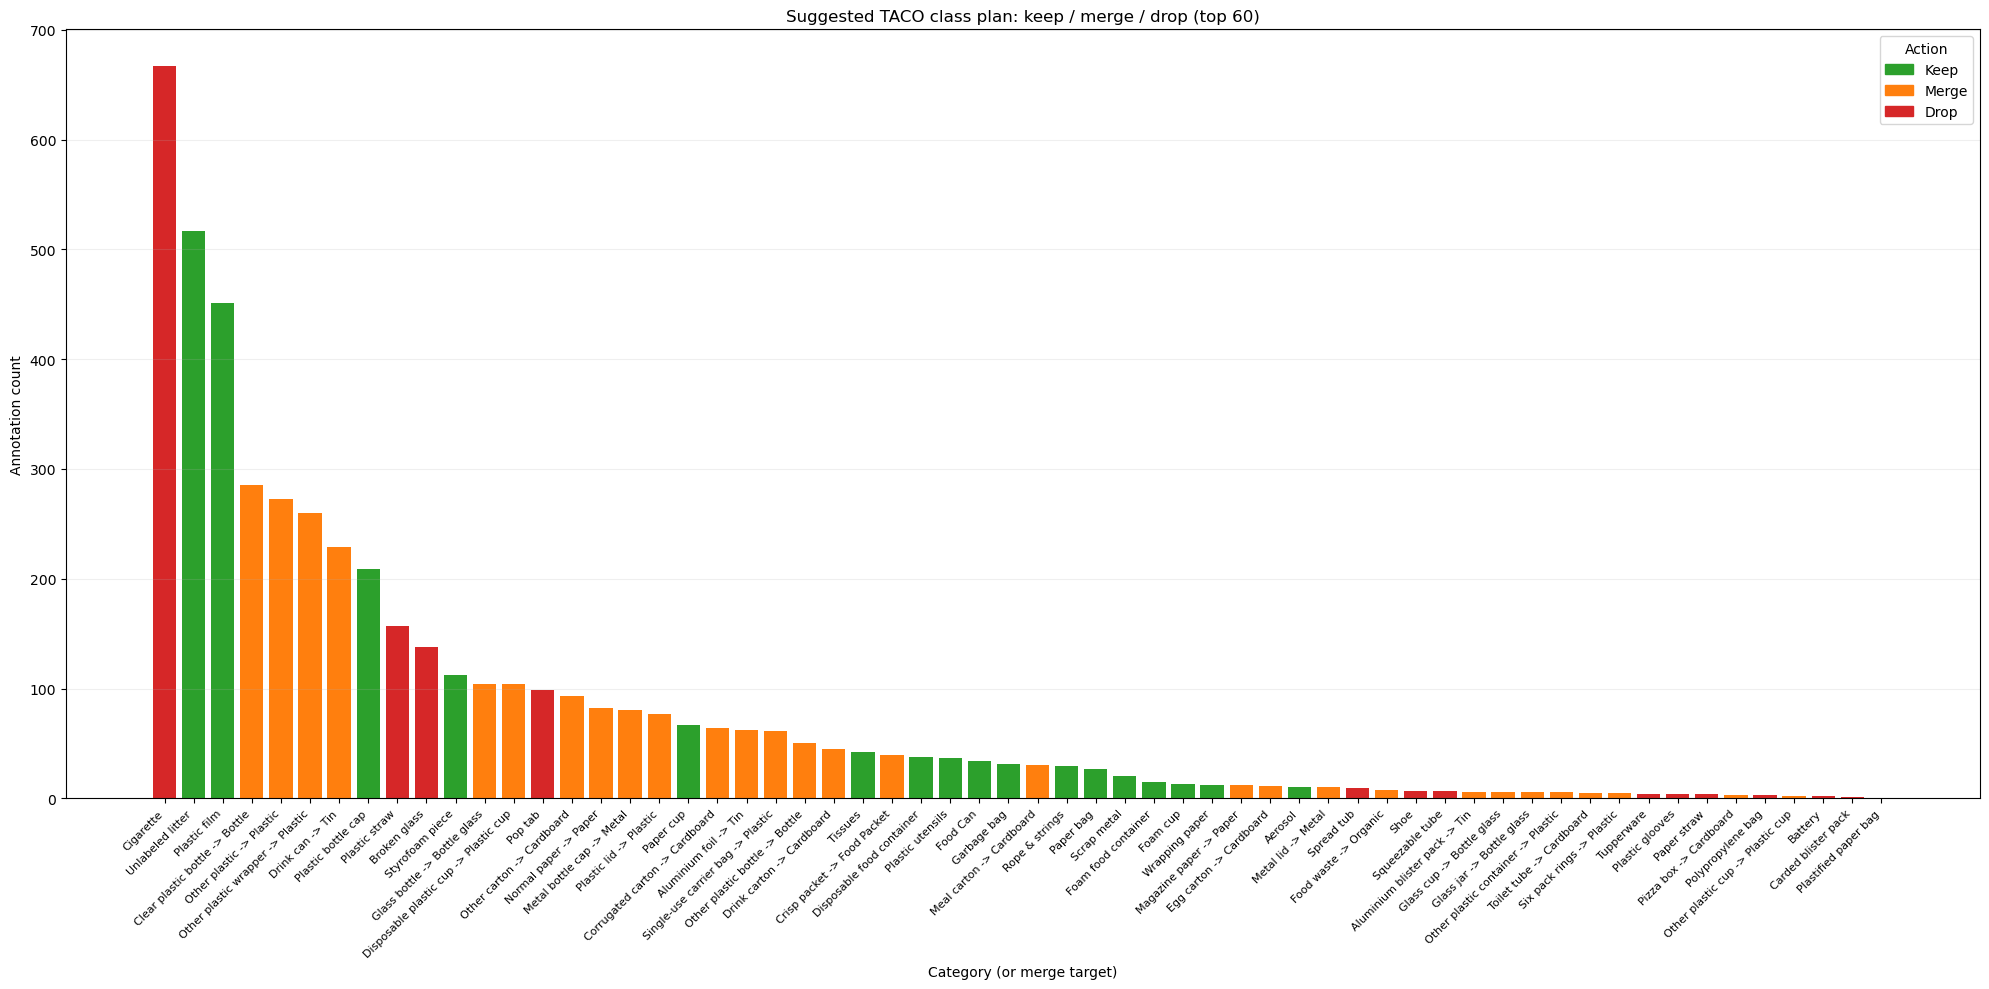

Suggested plan plot saved to: dataset/taco_yolo_dataset/suggested_class_plan.png


/tmp/ipykernel_1201/850099424.py:182: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(final_labels, rotation=45, ha='right', fontsize=8)


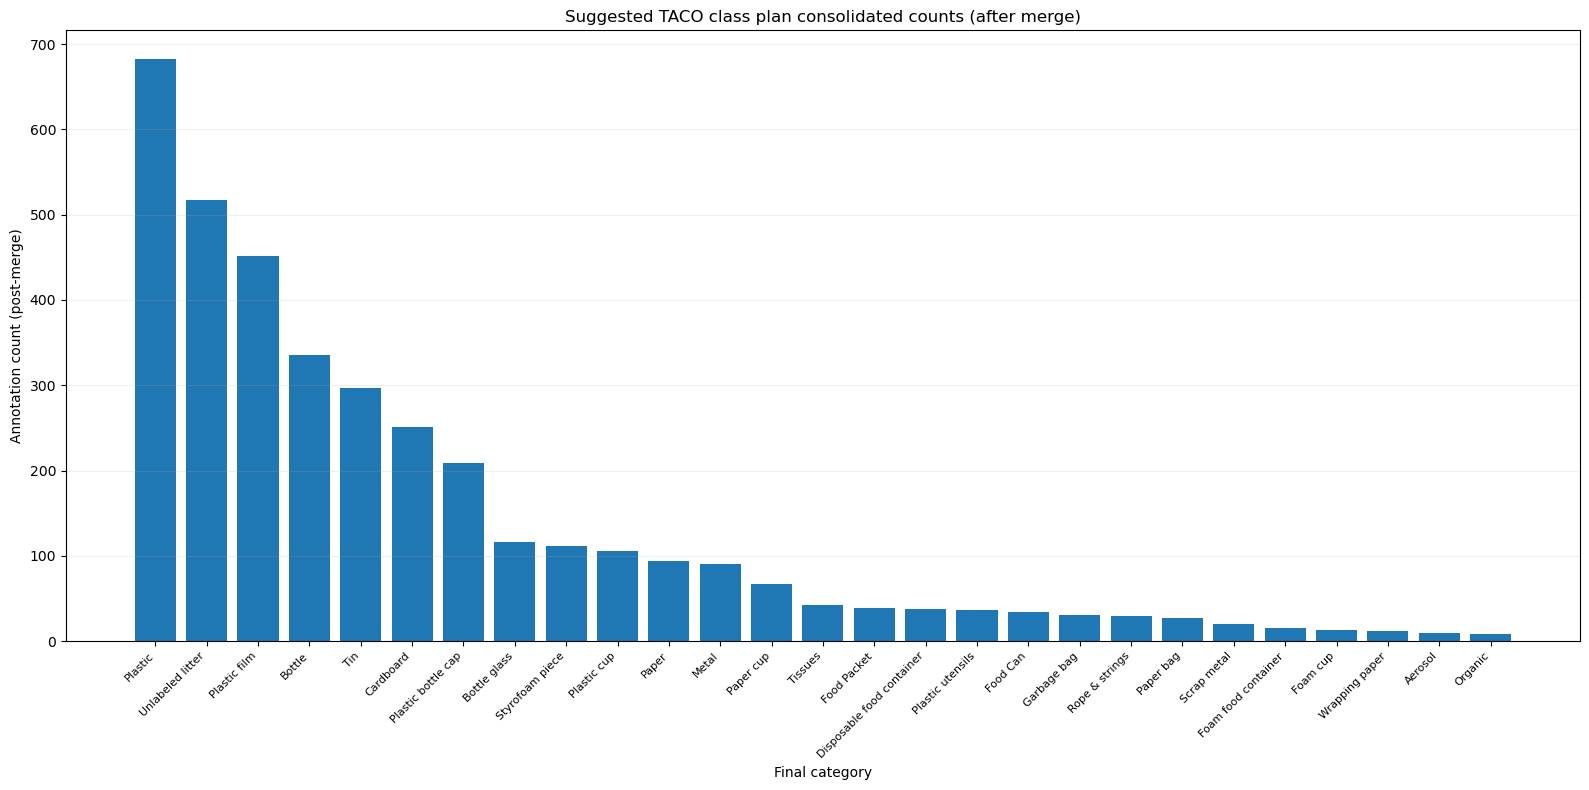

Suggested plan consolidated plot saved to: dataset/taco_yolo_dataset/suggested_class_plan_consolidated.png

Generating category report and plot...
Category report saved to: dataset/taco_yolo_dataset/category_frequency.csv


/tmp/ipykernel_1201/850099424.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top['category_name'], rotation=45, ha='right', fontsize=8)


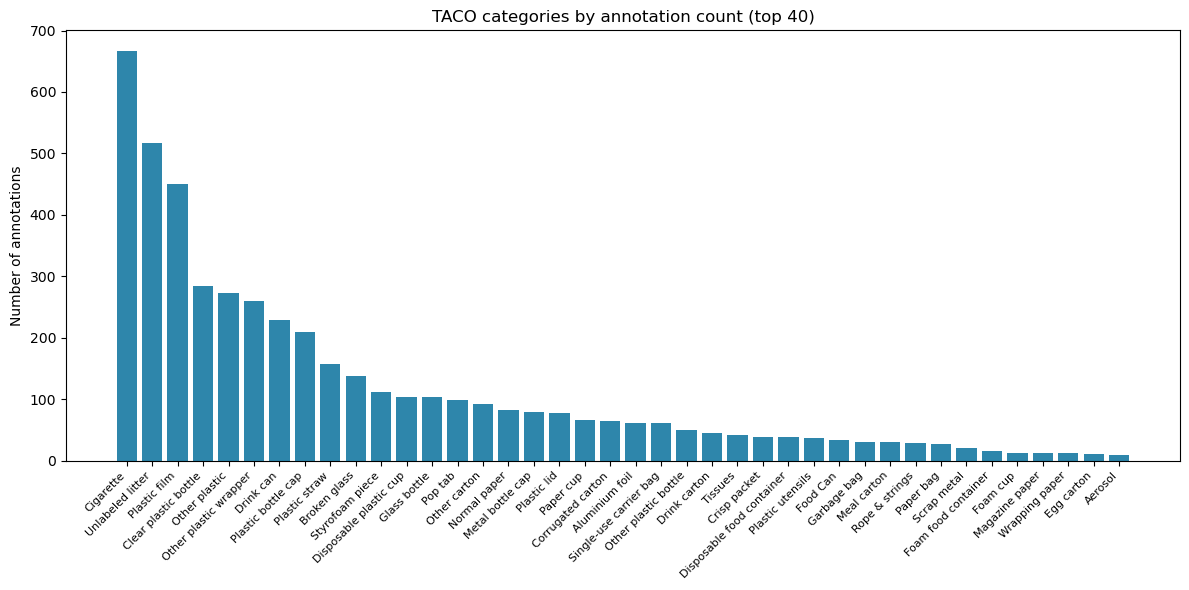

Frequency plot saved to: dataset/taco_yolo_dataset/category_frequency_top40.png
Number of mapped images available: 1500
Building subset train: 1200 images
  train: processed 100/1200 images
  train: processed 200/1200 images
  train: processed 300/1200 images
  train: processed 400/1200 images
  train: processed 500/1200 images
  train: processed 600/1200 images
  train: processed 700/1200 images
  train: processed 800/1200 images
  train: processed 900/1200 images
  train: processed 1000/1200 images
  train: processed 1100/1200 images
  train: processed 1200/1200 images
Building subset val: 150 images
  val: processed 100/150 images
Building subset test: 150 images
  test: processed 100/150 images
YOLO dataset built at: dataset/taco_yolo_dataset
Classes: 26
Train images: 1200, valid images: 150, test images: 150
Total labels written: 3136

Created data.yaml at dataset/taco_yolo_dataset/data.yaml


In [10]:
# Paramètres utilisateur

# Ajustez ces chemins si nécessaire
taco_root_candidates = [Path('TACO-master'), Path('dataset/TACO-master')]
taco_root = next((p for p in taco_root_candidates if p.exists()), taco_root_candidates[0])
output_root = Path('dataset/taco_yolo_dataset')

# True pour télécharger les images depuis les URLs de annotations.json
download_images = True

# Limiter le téléchargement / traitement pour tester plus vite
max_images = None  # ou un entier, par exemple 200

# Split train/val/test
split = (0.8, 0.1, 0.1)
seed = 42

# Générer le rapport et le graphe
plot = True

# Afficher la suggestion de plan de fusion / drop des classes
suggest_plan = True

# Chercher des exemples pour une catégorie TACO (optionnel)
find_category = None  # ex. 1

print('TACO root:', taco_root.resolve())
print('Output root:', output_root.resolve())
print('Download images from annotations.json URLs:', download_images)
print('Max images:', max_images)
print('Split:', split)

if not taco_root.exists():
    tried = ', '.join(str(p) for p in taco_root_candidates)
    raise FileNotFoundError(f'TACO root non trouvé. Chemins testés: {tried}')

json_path = taco_root / 'data' / 'annotations.json'
if not json_path.exists():
    raise FileNotFoundError(f'Fichier annotations.json non trouvé: {json_path}')

# Prépare le dossier local des images TACO
# Si download_images=False, on utilisera les images déjà présentes dans ce dossier.
taco_images_dir = taco_root / 'data' / 'images'
taco_images_dir.mkdir(parents=True, exist_ok=True)

# Lecture des métadonnées TACO
images_meta, annotations, categories = read_taco_json(json_path)
print(f'Loaded annotations for {len(images_meta)} images, {len(annotations)} annotated images, {len(categories)} categories.')

# Téléchargement ou mapping existant
if download_images:
    print('Downloading TACO images from annotations.json URLs...')
    taco_images = download_taco_images(images_meta, taco_images_dir, max_images=max_images)
else:
    print('Skipping download. Using existing images inside:', taco_images_dir)
    taco_images = {}
    for image_id, image_info in images_meta.items():
        parsed_name = Path(image_info['file_name']).name
        local_name = f"{image_id:05d}_{sanitize_image_name(parsed_name)}"
        candidate = taco_images_dir / local_name
        if candidate.exists():
            taco_images[image_id] = candidate
        if max_images is not None and len(taco_images) >= max_images:
            break

counts, image_counts = analyze_categories(categories, annotations)
print('\nTACO category overview:')
sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)
for cat_id, cnt in sorted_counts[:20]:
    print(f'  {cat_id:2d} {categories[cat_id]:30s} annotations={cnt:5d} images={image_counts.get(cat_id,0):5d}')

if suggest_plan:
    suggest_taco_class_plan(categories, counts, image_counts, output_root)

if find_category is not None:
    find_images_for_category(find_category, categories, annotations, images_meta, taco_images, max_examples=20)

if plot:
    output_root.mkdir(parents=True, exist_ok=True)
    print('\nGenerating category report and plot...')
    create_category_report(categories, counts, image_counts, output_root)

print(f'Number of mapped images available: {len(taco_images)}')
if not taco_images:
    raise RuntimeError(f'No images found to process. Run with download_images=True or place downloaded images in {taco_images_dir}')

mapped_category_ids, yolo_names = build_taco_category_mapping(categories)
build_yolo_dataset(
    taco_images,
    images_meta,
    annotations,
    categories,
    output_root,
    split=split,
    seed=seed,
    category_mapping=mapped_category_ids,
    yolo_names=yolo_names,
)
print('\nCreated data.yaml at', output_root / 'data.yaml')
